# Notebook 02: NMF decomposition

This notebook performs non-negative matrix factorization (NMF) on the participant-level feature matrix, with stability analysis to select an appropriate number of components.

**Inputs (from Notebook 01):**
- `outputs/feature_matrix.csv` — normalized participants × features matrix

**Outputs:**
- `outputs/nmf_diagnostics.csv` — reconstruction error and stability across k
- `outputs/nmf_W.csv` — final participant × component embedding
- `outputs/nmf_H.csv` — final component × feature loadings
- `outputs/nmf_chosen_k.txt` — the chosen k value and rationale

## What NMF does, briefly

Given the data matrix `X` (participants × features), NMF finds two non-negative matrices `W` (participants × k) and `H` (k × features) such that `W @ H ≈ X`. Each of the `k` components represents a recurring pattern of feature co-activation across participants. Participants are described as non-negative combinations of these components.

Two practical issues:
1. **NMF is non-convex** — different random initializations can give different solutions, especially with high-dimensional data. We address this by running many initializations and assessing stability.
2. **k must be chosen** — reconstruction error decreases monotonically with k, so it doesn't tell us where to stop. We pair it with stability analysis: a 'good' k is one where the components recovered are reproducible across random restarts.

## Setup

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.decomposition import NMF
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt

PROJECT_ROOT = Path(".").resolve().parent
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)

# Configuration
K_RANGE = list(range(2, 16))      # k = 2 to 15
N_INIT = 50                        # initializations per k
RANDOM_SEED_BASE = 42              # base seed for reproducibility
MAX_ITER = 500                     # NMF iterations
TOL = 1e-4                         # NMF convergence tolerance

print(f"Testing k = {K_RANGE[0]} to {K_RANGE[-1]} ({len(K_RANGE)} values)")
print(f"Initializations per k: {N_INIT}")
print(f"Total NMF fits: {len(K_RANGE) * N_INIT}")

Testing k = 2 to 15 (14 values)
Initializations per k: 50
Total NMF fits: 700


## Load feature matrix

In [3]:
feature_matrix = pd.read_csv(OUTPUT_DIR / "feature_matrix.csv", index_col="participant_id")
X = feature_matrix.values
print(f"Feature matrix shape: {X.shape}")
print(f"Value range: [{X.min():.4f}, {X.max():.4f}]")
print(f"All non-negative (required for NMF): {(X >= 0).all()}")

Feature matrix shape: (86, 350)
Value range: [0.0000, 1.0000]
All non-negative (required for NMF): True


## Helper: match components across runs

To assess stability, we need to compare components produced by different random initializations. But NMF doesn't guarantee component ordering — run 1's component 3 might correspond to run 2's component 7. We use the Hungarian algorithm to find the best one-to-one matching based on cosine similarity, then measure how well-matched the components are.

In [4]:
def cosine_similarity_matrix(A, B):
    """Compute pairwise cosine similarity between rows of A and B.
    Returns shape (n_A, n_B)."""
    A_norm = A / (np.linalg.norm(A, axis=1, keepdims=True) + 1e-12)
    B_norm = B / (np.linalg.norm(B, axis=1, keepdims=True) + 1e-12)
    return A_norm @ B_norm.T

def match_and_score(H1, H2):
    """Match components in H2 to components in H1 by cosine similarity.
    Returns mean similarity of best matching."""
    sim = cosine_similarity_matrix(H1, H2)
    # Hungarian: maximize sum of similarities -> minimize sum of (1 - similarity)
    row_ind, col_ind = linear_sum_assignment(-sim)
    return sim[row_ind, col_ind].mean()

## Run NMF across k with stability analysis

For each k:
- Run NMF `N_INIT` times with different seeds
- Record reconstruction error for each
- Compute pairwise stability: for each pair of runs at the same k, how similar are their components?
- Higher mean pairwise similarity = more stable solution = more trustworthy k

This step is the slowest in the notebook. With k = 2 to 10 and 50 inits, expect roughly 5-15 minutes depending on your machine.

In [5]:
import time
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)

diagnostics = []
all_H = {}  # store all H matrices by (k, init_idx) for stability computation
all_errors = {}  # store reconstruction errors by k

start = time.time()
for k in K_RANGE:
    Hs = []
    errors = []
    t_k = time.time()
    for i in range(N_INIT):
        model = NMF(
            n_components=k,
            init="random",
            random_state=RANDOM_SEED_BASE + i,
            max_iter=MAX_ITER,
            tol=TOL,
            beta_loss="frobenius",
            solver="cd"
        )
        W = model.fit_transform(X)
        H = model.components_
        Hs.append(H)
        errors.append(model.reconstruction_err_)

    all_H[k] = Hs
    all_errors[k] = errors

    # Pairwise stability: average match across all pairs of runs at this k
    pairwise_scores = []
    for i in range(N_INIT):
        for j in range(i + 1, N_INIT):
            pairwise_scores.append(match_and_score(Hs[i], Hs[j]))
    stability = np.mean(pairwise_scores)
    stability_std = np.std(pairwise_scores)

    diagnostics.append({
        "k": k,
        "mean_recon_error": np.mean(errors),
        "std_recon_error": np.std(errors),
        "min_recon_error": np.min(errors),
        "stability_mean": stability,
        "stability_std": stability_std,
    })
    elapsed_k = time.time() - t_k
    print(f"k={k:2d} | recon error: {np.mean(errors):.4f} ± {np.std(errors):.4f} | "
          f"stability: {stability:.4f} ± {stability_std:.4f} | {elapsed_k:.1f}s")

print(f"\nTotal time: {time.time() - start:.1f}s")

diag_df = pd.DataFrame(diagnostics)
diag_df.to_csv(OUTPUT_DIR / "nmf_diagnostics.csv", index=False)
diag_df

k= 2 | recon error: 26.7212 ± 0.0000 | stability: 1.0000 ± 0.0000 | 1.1s
k= 3 | recon error: 25.1560 ± 0.0004 | stability: 0.9990 ± 0.0012 | 2.1s
k= 4 | recon error: 23.8671 ± 0.0001 | stability: 0.9998 ± 0.0002 | 1.9s
k= 5 | recon error: 22.7875 ± 0.0069 | stability: 0.9865 ± 0.0168 | 2.3s
k= 6 | recon error: 21.8092 ± 0.0197 | stability: 0.9676 ± 0.0466 | 2.7s
k= 7 | recon error: 20.9679 ± 0.0383 | stability: 0.9440 ± 0.0585 | 2.9s
k= 8 | recon error: 20.2078 ± 0.0217 | stability: 0.9133 ± 0.0455 | 2.8s
k= 9 | recon error: 19.5050 ± 0.0255 | stability: 0.8860 ± 0.0466 | 6.2s
k=10 | recon error: 18.8022 ± 0.0269 | stability: 0.9048 ± 0.0444 | 6.1s
k=11 | recon error: 18.1474 ± 0.0330 | stability: 0.8996 ± 0.0468 | 6.4s
k=12 | recon error: 17.5343 ± 0.0320 | stability: 0.8936 ± 0.0429 | 6.3s
k=13 | recon error: 16.9394 ± 0.0300 | stability: 0.8843 ± 0.0380 | 6.8s
k=14 | recon error: 16.3421 ± 0.0383 | stability: 0.9011 ± 0.0384 | 7.0s
k=15 | recon error: 15.8302 ± 0.0299 | stability: 0

,k,mean_recon_error,std_recon_error,min_recon_error,stability_mean,stability_std
0,2,26.721202,6.894922e-07,26.721201,0.999996,0.000004
1,3,25.156020,4.214446e-04,25.155718,0.999026,0.001205
2,4,23.867111,6.863111e-05,23.867059,0.999804,0.000210
3,5,22.787466,6.867267e-03,22.785214,0.986538,0.016750
4,6,21.809178,1.965749e-02,21.799139,0.967556,0.046645
5,7,20.967947,3.832276e-02,20.944246,0.943976,0.058532
6,8,20.207796,2.172323e-02,20.175129,0.913263,0.045450
7,9,19.504987,2.551942e-02,19.468358,0.885954,0.046580
8,10,18.802198,2.686300e-02,18.758307,0.904835,0.044368
9,11,18.147428,3.295963e-02,18.104278,0.899567,0.046756


## Visualize diagnostics

Two side-by-side plots: reconstruction error (should decrease with k) and stability (should ideally show a peak or plateau before falling off).

**How to read these:**
- Reconstruction error always decreases as k grows — that's just because more components = better fit. We're looking for a *kink* or *elbow* where the rate of improvement slows.
- Stability tells us how reproducible the solution is. High stability = different random initializations converge to similar components. Low stability = the optimization is finding very different solutions each time, which means the components are unreliable.
- The best k is usually one with high stability and reasonable reconstruction error — not necessarily the lowest error, not necessarily the highest stability.

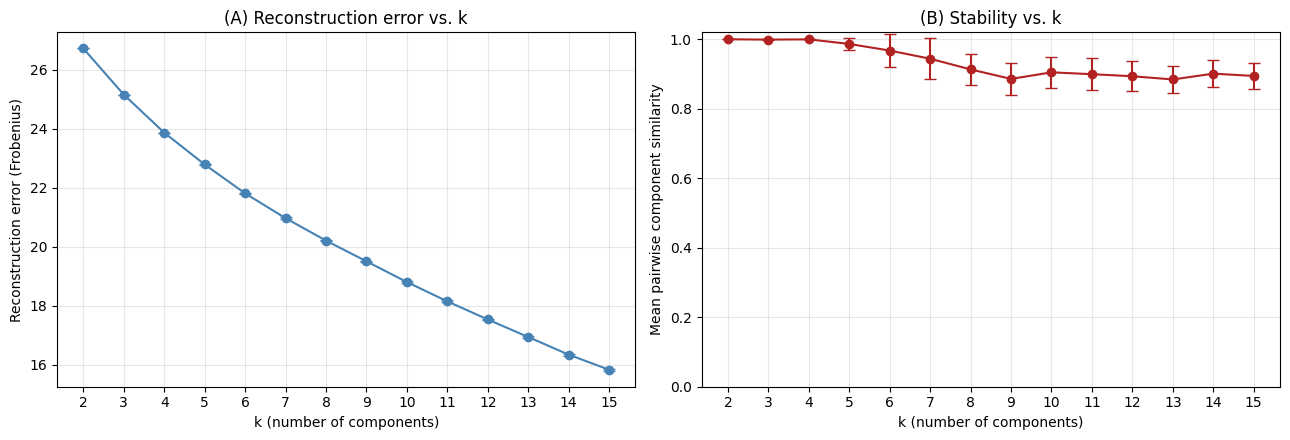

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].errorbar(diag_df["k"], diag_df["mean_recon_error"],
                 yerr=diag_df["std_recon_error"], marker="o", capsize=4, color="steelblue")
axes[0].set_xlabel("k (number of components)")
axes[0].set_ylabel("Reconstruction error (Frobenius)")
axes[0].set_title("(A) Reconstruction error vs. k")
axes[0].grid(alpha=0.3)
axes[0].set_xticks(K_RANGE)

axes[1].errorbar(diag_df["k"], diag_df["stability_mean"],
                 yerr=diag_df["stability_std"], marker="o", capsize=4, color="firebrick")
axes[1].set_xlabel("k (number of components)")
axes[1].set_ylabel("Mean pairwise component similarity")
axes[1].set_title("(B) Stability vs. k")
axes[1].set_ylim(0, 1.02)
axes[1].grid(alpha=0.3)
axes[1].set_xticks(K_RANGE)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nmf_diagnostics_plot.png", dpi=150, bbox_inches="tight")
plt.show()

## Choose k

Looking at the plots above, pick a k that balances good reconstruction with good stability. After you decide, set `CHOSEN_K` in the next cell.

Common heuristics:
- Pick the k just before stability drops sharply
- Pick the highest k where stability is above some threshold (e.g., > 0.85)
- Pick the elbow of the reconstruction-error curve if stability is comparable across that range

We'll discuss the actual values before committing.

In [7]:
# >>> EDIT THIS AFTER REVIEWING THE PLOTS <<<
CHOSEN_K = 5  # placeholder — change based on diagnostics
RATIONALE = "Satisfactory complexity, stability and reconstruction error."

print(f"Chosen k: {CHOSEN_K}")
print(f"Rationale: {RATIONALE}")

# Save rationale
with open(OUTPUT_DIR / "nmf_chosen_k.txt", "w", encoding="utf-8") as f:
    f.write(f"chosen_k: {CHOSEN_K}\n")
    f.write(f"rationale: {RATIONALE}\n")

Chosen k: 5
Rationale: Satisfactory complexity, stability and reconstruction error.


## Fit final model at chosen k

Among the `N_INIT` runs at the chosen k, we pick the one with the lowest reconstruction error as the final solution. This is the standard 'best of N' approach for non-convex NMF.

In [8]:
# Find best init at chosen k
errors_at_k = all_errors[CHOSEN_K]
best_init = int(np.argmin(errors_at_k))
print(f"Best init at k={CHOSEN_K}: index {best_init} with error {errors_at_k[best_init]:.4f}")

# Refit to get both W and H (we only stored H during the stability sweep)
final_model = NMF(
    n_components=CHOSEN_K,
    init="random",
    random_state=RANDOM_SEED_BASE + best_init,
    max_iter=MAX_ITER,
    tol=TOL,
    beta_loss="frobenius",
    solver="cd"
)
W = final_model.fit_transform(X)
H = final_model.components_

# Sanity-check: error should match the stored one (within tiny float noise)
print(f"Refit reconstruction error: {final_model.reconstruction_err_:.4f}")

# Wrap in DataFrames with informative labels
component_labels = [f"comp_{i+1}" for i in range(CHOSEN_K)]
W_df = pd.DataFrame(W, index=feature_matrix.index, columns=component_labels)
H_df = pd.DataFrame(H, index=component_labels, columns=feature_matrix.columns)

W_df.to_csv(OUTPUT_DIR / "nmf_W.csv")
H_df.to_csv(OUTPUT_DIR / "nmf_H.csv")

print(f"\n✓ Saved W ({W_df.shape}) and H ({H_df.shape})")

Best init at k=5: index 33 with error 22.7852
Refit reconstruction error: 22.7852

✓ Saved W ((86, 5)) and H ((5, 350))


## Inspect components

Each component is a non-negative weighted combination of all 2,520 features. To interpret what a component represents, we look at which features have the highest loadings.

Below: for each component, the top 15 features by absolute loading. We also break down which (band × channel × stimulus) cells dominate.

In [9]:
def parse_feature_name(name):
    """Split '{stimulus}__POW.{channel}.{band}' into parts."""
    stim, pow_part = name.split("__", 1)
    _, channel, band = pow_part.split(".")
    return stim, channel, band

for comp in component_labels:
    print(f"\n=== {comp} ===")
    top = H_df.loc[comp].nlargest(15)
    for feat, val in top.items():
        stim, ch, band = parse_feature_name(feat)
        print(f"  {val:.4f}  {stim:35s}  {ch:5s}  {band}")


=== comp_1 ===
  0.4909  frontal                              AF3    Theta
  0.4777  frontal_central                      AF4    Alpha
  0.4672  frontal                              AF3    Alpha
  0.4530  frontal_central                      AF4    Theta
  0.4524  frontal_central                      AF3    Alpha
  0.4488  temporal                             AF4    Alpha
  0.4444  frontal_central                      AF3    BetaL
  0.4404  temporal                             AF3    Alpha
  0.4361  temporal                             AF4    Theta
  0.4246  temporal                             F7     Alpha
  0.4174  frontal_central                      AF3    Theta
  0.4148  frontal                              AF4    Theta
  0.4129  frontal_central                      AF4    BetaL
  0.4097  temporal                             AF3    Theta
  0.4086  frontal                              AF3    BetaL

=== comp_2 ===
  0.6163  temporal                             O2     Theta
  0.6095

In [10]:
# Aggregate loadings by frequency band, channel, and stimulus to see which dominate
for comp in component_labels:
    loadings = H_df.loc[comp]
    parsed = pd.DataFrame({
        "loading": loadings.values,
        "stim": [parse_feature_name(n)[0] for n in loadings.index],
        "channel": [parse_feature_name(n)[1] for n in loadings.index],
        "band": [parse_feature_name(n)[2] for n in loadings.index],
    })
    by_band = parsed.groupby("band")["loading"].sum().sort_values(ascending=False)
    by_chan = parsed.groupby("channel")["loading"].sum().sort_values(ascending=False)
    print(f"\n=== {comp} aggregates ===")
    print("  Top bands:    ", dict(by_band.round(2).head(3)))
    print("  Top channels: ", dict(by_chan.round(2).head(5)))


=== comp_1 aggregates ===
  Top bands:     {'Alpha': 14.09, 'Theta': 13.94, 'BetaL': 11.61}
  Top channels:  {'AF3': 8.62, 'AF4': 7.79, 'F7': 6.81, 'F3': 6.39, 'FC5': 5.42}

=== comp_2 aggregates ===
  Top bands:     {'Theta': 29.72, 'Alpha': 16.71, 'BetaL': 9.46}
  Top channels:  {'P8': 8.62, 'T8': 6.7, 'O1': 6.27, 'O2': 5.95, 'F8': 5.74}

=== comp_3 aggregates ===
  Top bands:     {'Theta': 23.52, 'Alpha': 17.26, 'BetaL': 17.04}
  Top channels:  {'T7': 14.57, 'P7': 14.33, 'FC5': 9.53, 'F3': 9.01, 'O1': 7.51}

=== comp_4 aggregates ===
  Top bands:     {'BetaL': 35.21, 'Alpha': 33.17, 'BetaH': 18.08}
  Top channels:  {'F4': 11.8, 'FC6': 10.42, 'O2': 9.74, 'F3': 9.7, 'AF4': 8.59}

=== comp_5 aggregates ===
  Top bands:     {'Gamma': 48.06, 'BetaH': 38.2, 'BetaL': 18.75}
  Top channels:  {'AF4': 10.32, 'F7': 9.96, 'P8': 9.65, 'T8': 9.45, 'O1': 9.23}


## Component loading heatmap

Visual overview of how each component weights different (band × channel) combinations, averaged across stimuli.

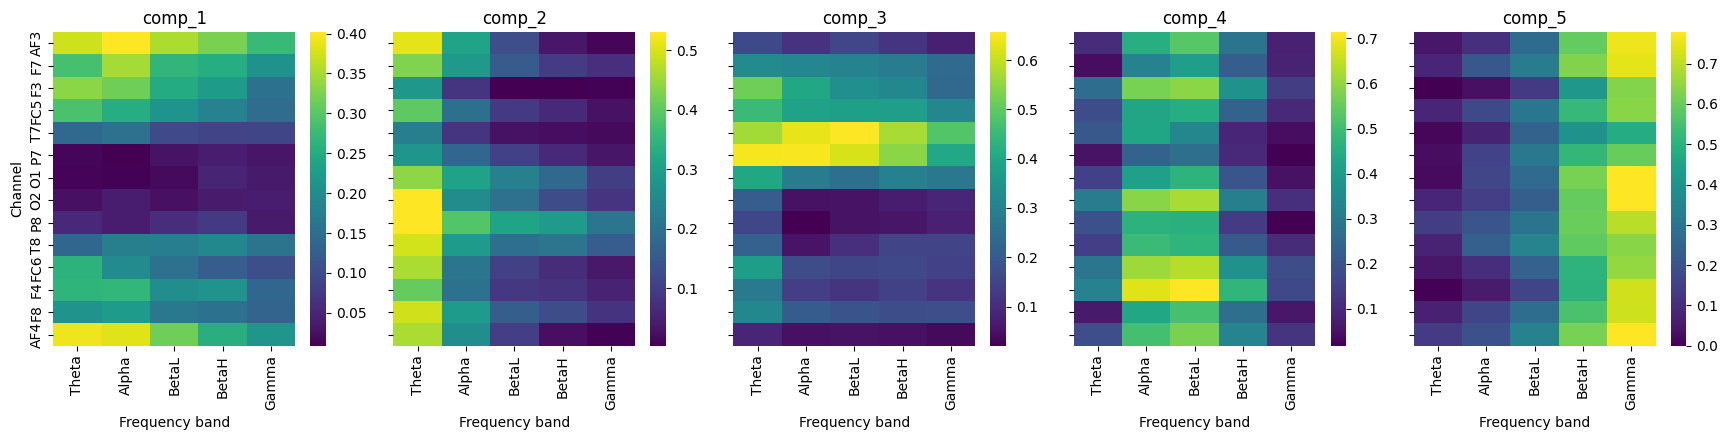

In [11]:
import seaborn as sns

FREQ_BANDS = ["Theta", "Alpha", "BetaL", "BetaH", "Gamma"]
CHANNELS = ["AF3", "F7", "F3", "FC5", "T7", "P7", "O1",
            "O2", "P8", "T8", "FC6", "F4", "F8", "AF4"]

fig, axes = plt.subplots(1, CHOSEN_K, figsize=(3.5 * CHOSEN_K, 4.5), sharey=True)
if CHOSEN_K == 1:
    axes = [axes]

for ax, comp in zip(axes, component_labels):
    loadings = H_df.loc[comp]
    parsed = pd.DataFrame({
        "loading": loadings.values,
        "channel": [parse_feature_name(n)[1] for n in loadings.index],
        "band":    [parse_feature_name(n)[2] for n in loadings.index],
    })
    avg = parsed.groupby(["channel", "band"])["loading"].mean().unstack()
    avg = avg.reindex(index=CHANNELS, columns=FREQ_BANDS)
    sns.heatmap(avg, ax=ax, cmap="viridis", cbar=True, xticklabels=True, yticklabels=True)
    ax.set_title(comp)
    ax.set_xlabel("Frequency band")
    if ax is axes[0]:
        ax.set_ylabel("Channel")
    else:
        ax.set_ylabel("")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "nmf_component_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary of W (participant embedding)

Participant × component embedding (W) — descriptive stats:
       comp_1  comp_2  comp_3  comp_4  comp_5
count  86.000  86.000  86.000  86.000  86.000
mean    0.386   0.389   0.249   0.319   0.239
std     0.330   0.286   0.223   0.287   0.250
min     0.000   0.000   0.000   0.000   0.000
25%     0.160   0.188   0.065   0.098   0.035
50%     0.342   0.336   0.202   0.243   0.157
75%     0.550   0.521   0.365   0.468   0.355
max     1.773   1.110   0.885   1.162   0.984


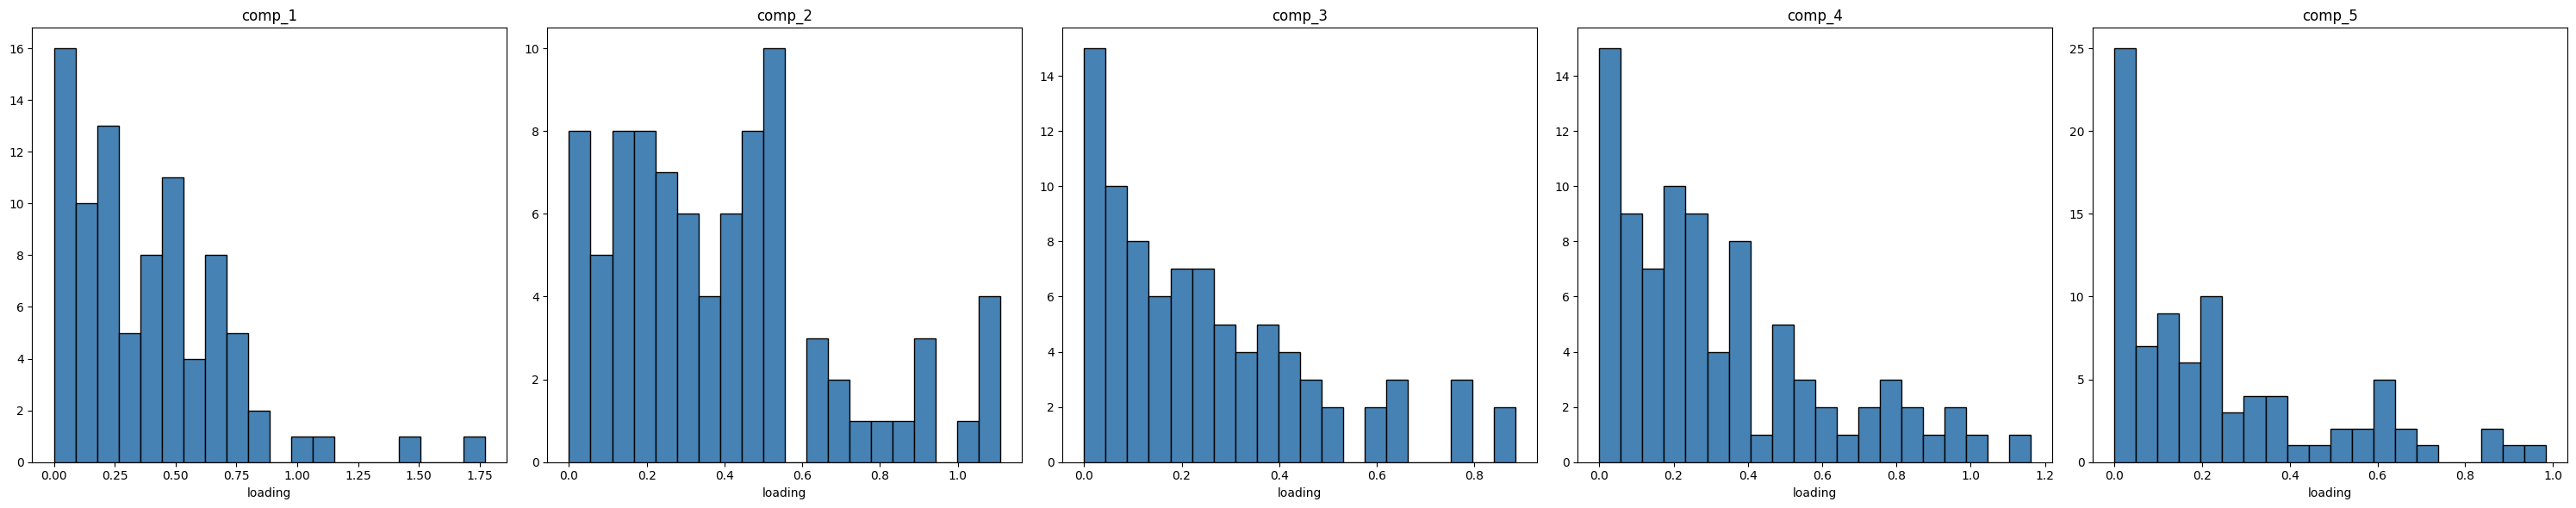

In [14]:
print("Participant × component embedding (W) — descriptive stats:")
print(W_df.describe().round(3))

# Distribution of each component across participants
fig, axes = plt.subplots(1, CHOSEN_K, figsize=(6 * CHOSEN_K, 6))
if CHOSEN_K == 1:
    axes = [axes]
for ax, comp in zip(axes, component_labels):
    ax.hist(W_df[comp], bins=20, color="steelblue", edgecolor="black")
    ax.set_title(comp)
    ax.set_xlabel("loading")
plt.tight_layout()
plt.show()